
# NASSAU CANDY DISTRIBUTOR - DATA PROCESSING & ANALYSIS

## Project Description

This project focuses on the complete **data processing and analysis** of the Nassau Candy Distributor dataset. The objective of this analysis is to clean, transform, and explore the dataset in order to generate meaningful insights about product distribution, sales patterns, and business operations.

## Workflow

The project includes several important data science steps:

- Data Loading  
- Data Cleaning  
- Handling Missing Values  
- Removing Duplicates  
- Data Type Conversion  
- Exploratory Data Analysis (EDA)

These steps ensure the dataset becomes accurate, consistent, and ready for analysis.

## Objective

The main goal of this project is to understand:

- Product categories
- Pricing patterns
- Distribution trends
- Business insights from the dataset

## Tools & Technologies

- Python  
- Pandas  
- NumPy  
- Matplotlib  
- Seaborn



# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Loading the dataset

In [2]:
df = pd.read_csv('C:/Users/Neeraj_Thakur/OneDrive/Documents/Nassau Candy Distributor/data/nassau_candy_distributor.csv')

print("Loading data...")
 
try:
    df = pd.read_csv('C:/Users/Neeraj_Thakur/OneDrive/Documents/Nassau Candy Distributor/data/nassau_candy_distributor.csv')
    print(f"Data loaded successfully: {df.shape[0]:,} records, {df.shape[1]} columns")
except FileNotFoundError:
    print("Error: CSV file not found. Ensure 'C:/Users/Neeraj_Thakur/OneDrive/Documents/Nassau Candy Distributor/data/nassau_candy_distributor.csv' is in current directory")
    exit()

Loading data...
Data loaded successfully: 10,194 records, 18 columns


# 3. Data inspection

In [3]:
print("Inspecting data structure...")
 
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names & Types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nBasic Statistics:")
print(df.describe())


Inspecting data structure...

Dataset Shape: (10194, 18)

Column Names & Types:
Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

First 5 rows:
   Row ID                      Order ID  Order Date   Ship Date  \
0       1  US-2021-103800-CHO-MIL-31000  03-01-2024  30-06-2026   
1       2  US-2021-112326-CHO-TRI-54000  04-01-2024  01-07-2026   
2       3  US-2021-112326-CHO-NUT-13000  04-01-2024  01-07-2026   
3       4  US-2021-112326-CHO-SCR-58000  04-01-2024  01-07-2026   
4       5  US-2021-141817-CHO-TRI-54000  05-01-2024  05-07-2026   

        Ship Mode  C

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


# 4. Data Cleaning & Preprocessing

Data cleaning is crucial for removing inconsistencies and preparing the dataset for analysis.

### Date Format Standardization

In [5]:
# Convert date columns to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

# check data types after conversion order date and ship date
df.dtypes[['Order Date', 'Ship Date']]

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

### Invalid Records Removal

In [6]:
# # Remove records where Ship Date < Order Date
# df = df[df['Ship Date'] >= df['Order Date']]

# # Remove records with negative lead times
# df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days
# df = df[df['Lead Time'] >= 0]

# # Remove extreme outliers (>365 days)
# df = df[df['Lead Time'] <= 365]


# Store original shape
original_rows = len(df)
print(f"Original Record Count: {original_rows}")
 
# Remove records with invalid dates
df = df.dropna(subset=['Order Date', 'Ship Date'])
print(f"Removed {original_rows - len(df)} records with invalid dates")


Original Record Count: 10194
Removed 0 records with invalid dates


### Removing Duplicates

Ensure each record is unique and represents a single transaction.

In [7]:
# Identify and remove duplicate records
duplicates = df.duplicated()
print(f"Duplicate Records Found: {duplicates.sum()}")

# Remove duplicates
df = df.drop_duplicates()

# Verify removal
print(f"Final Record Count: {len(df)}")


Duplicate Records Found: 0
Final Record Count: 10194


### NOTE :- `No duplicate records found in the dataset, so nothing to remove here.`

### Missing Values Handling

In [8]:
# Check for missing values in critical columns
critical_cols = ['Order ID', 'Order Date', 'Ship Date', 'State/Province', 'Product Name']
for col in critical_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        print(f"  - Removed {missing} records with missing {col}")
        df = df.dropna(subset=[col])
 
print(f"Data cleaning complete: {len(df):,} records remaining")

Data cleaning complete: 10,194 records remaining


### NOTE :- `No missing values found in the dataset, so nothing to handle here.`

# 5. Feature Engineering

### 5.1 Calculate Lead Time 

In [9]:
print("  - Calculating lead times...")
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

  - Calculating lead times...


In [10]:
# Check for invalid lead times
invalid_lt = len(df[df['Lead Time'] < 0])
if invalid_lt > 0:
    print(f"    Removed {invalid_lt} records with negative lead times")
    df = df[df['Lead Time'] >= 0]

In [11]:
# Remove extreme outliers (> 365 days)
outlier_count = len(df[df['Lead Time'] > 365])
if outlier_count > 0:
    print(f"Flagged {outlier_count} records with lead time > 365 days")

Flagged 10194 records with lead time > 365 days


In [12]:
# Remove extreme outliers (> 365 days)
outlier_count = len(df[df['Lead Time'] > 365])
if outlier_count > 0:
    print(f"    Flagged {outlier_count} records with lead time > 365 days")
    # Keep them for analysis but flag
    df['Is_Outlier'] = df['Lead Time'] > 365
else:
    df['Is_Outlier'] = False
 
print(f"    Lead Time Range: {df['Lead Time'].min()} - {df['Lead Time'].max()} days")
print(f"    Average Lead Time: {df['Lead Time'].mean():.2f} days")

    Flagged 10194 records with lead time > 365 days
    Lead Time Range: 904 - 1642 days
    Average Lead Time: 1320.84 days


### 5.2 Create Product-Factory Mapping

In [13]:
print("Mapping products to factories...")
 
product_factory_map = {
    'Wonka Bar - Nutty Crunch Surprise': "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows': "Lot's O' Nuts",
    'Wonka Bar -Scrumdiddlyumptious': "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate': "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel': "Wicked Choccy's",
    'Laffy Taffy': "Sugar Shack",
    'SweeTARTS': "Sugar Shack",
    'Nerds': "Sugar Shack",
    'Fun Dip': "Sugar Shack",
    'Fizzy Lifting Drinks': "Sugar Shack",
    'Everlasting Gobstopper': "Secret Factory",
    'Hair Toffee': "The Other Factory",
    'Lickable Wallpaper': "Secret Factory",
    'Wonka Gum': "Secret Factory",
    'Kazookles': "The Other Factory"
}

df['Factory'] = df['Product Name'].map(product_factory_map)

Mapping products to factories...


In [14]:
# Check for unmapped products
unmapped = df[df['Factory'].isna()]['Product Name'].unique()
if len(unmapped) > 0:
    print(f"Warning: {len(unmapped)} unmapped products:")
    for prod in unmapped:
        print(f"{prod}")
else:
    print(f"All products mapped to factories")

All products mapped to factories


### 5.3 Add Factory Coordinates

In [15]:

print("Adding factory coordinates...")
 
factory_coords = {
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.11914, -96.18115),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.1175, -89.971107)
}

df['Factory Lat'] = df['Factory'].map(lambda x: factory_coords.get(x, (None, None))[0])
df['Factory Lon'] = df['Factory'].map(lambda x: factory_coords.get(x, (None, None))[1])

Adding factory coordinates...


### 5.4 Create Route Definition

In [16]:
print("Defining routes...")
 
df['Route'] = df.apply(
    lambda row: f"{row['Factory']} - {row['State/Province']}", 
    axis=1
)
 
df['Route_Simple'] = df.apply(
    lambda row: f"{row['Factory'][:3]} - {row['State/Province'][:3]}", 
    axis=1
)

Defining routes...


### 5.5 Create Route with Ship Mode

In [17]:

df['Route_Mode'] = df.apply(
    lambda row: f"{row['Factory']} ({row['Ship Mode']})", 
    axis=1
)

### 5.6 Add Time-based Features

In [18]:
print("Adding time-based features...")
 
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Quarter'] = df['Order Date'].dt.to_period('Q')
df['Order Year'] = df['Order Date'].dt.year
df['Order DayOfWeek'] = df['Order Date'].dt.day_name()
df['Ship Month'] = df['Ship Date'].dt.to_period('M')

Adding time-based features...


### 5.7 Lead Time Categorization


In [19]:
print(" Categorizing lead times...")
 
df['Lead_Time_Category'] = pd.cut(
    df['Lead Time'],
    bins=[0, 5, 10, 20, 365],
    labels=['Very Fast (0-5d)', 'Fast (5-10d)', 'Normal (10-20d)', 'Slow (20+d)']
)

 Categorizing lead times...


### 5.8 Efficiency Score (Normalized)

In [20]:
print("Calculating efficiency scores...")
 
min_lt = df['Lead Time'].min()
max_lt = df['Lead Time'].max()
 
df['Efficiency_Score'] = 100 - (
    (df['Lead Time'] - min_lt) / (max_lt - min_lt) * 100
)
 
print(f"Feature engineering complete: {len(df.columns)} columns created")

Calculating efficiency scores...
Feature engineering complete: 33 columns created


### NOTE :- `Feature engineering complete: 15 columns created`

In [21]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Route,Route_Simple,Route_Mode,Order Month,Order Quarter,Order Year,Order DayOfWeek,Ship Month,Lead_Time_Category,Efficiency_Score
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,Wicked Choccy's - Texas,Wic - Tex,Wicked Choccy's (Standard Class),2024-01,2024Q1,2024,Wednesday,2026-06,NaN,99.322493
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Wicked Choccy's - Illinois,Wic - Ill,Wicked Choccy's (Standard Class),2024-01,2024Q1,2024,Thursday,2026-07,NaN,99.322493
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Lot's O' Nuts - Illinois,Lot - Ill,Lot's O' Nuts (Standard Class),2024-01,2024Q1,2024,Thursday,2026-07,NaN,99.322493
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Lot's O' Nuts - Illinois,Lot - Ill,Lot's O' Nuts (Standard Class),2024-01,2024Q1,2024,Thursday,2026-07,NaN,99.322493
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,Wicked Choccy's - Pennsylvania,Wic - Pen,Wicked Choccy's (Standard Class),2024-01,2024Q1,2024,Friday,2026-07,NaN,98.915989


# 6. Expot the cleaned and processed dataset for further analysis or modeling.

In [22]:
# export cleaned and enriched dataset
output_path = 'C:/Users/Neeraj_Thakur/OneDrive/Documents/Nassau Candy Distributor/data/nassau_candy_distributor_cleaned.csv'
print(f"Exporting cleaned dataset to {output_path}...")
try:
    df.to_csv(output_path, index=False)
    print("Export successful!")
except Exception as e:
    print(f"Error exporting dataset: {e}")


Exporting cleaned dataset to C:/Users/Neeraj_Thakur/OneDrive/Documents/Nassau Candy Distributor/data/nassau_candy_distributor_cleaned.csv...
Export successful!


# 7. Exploratory Data Analysis (EDA)

### 7.1 Aggregate Route level Metrics 

In [23]:
print("Calculating route-level metrics...")
 
route_metrics = df.groupby('Route').agg({
    'Lead Time': ['mean', 'median', 'std', 'min', 'max', 'count'],
    'Sales': ['sum', 'mean'],
    'Gross Profit': ['sum', 'mean'],
    'Units': 'sum',
    'Order ID': 'count'
}).round(2)
 
route_metrics.columns = ['Avg_Lead_Time', 'Median_Lead_Time', 'StdDev_Lead_Time', 
                         'Min_Lead_Time', 'Max_Lead_Time', 'Order_Count',
                         'Total_Sales', 'Avg_Sales_Per_Order',
                         'Total_Profit', 'Avg_Profit_Per_Order', 'Total_Units', 'Total_Orders']
 
route_metrics = route_metrics.reset_index()

Calculating route-level metrics...


In [24]:
# Calculate efficiency score at route level
route_min_lt = route_metrics['Avg_Lead_Time'].min()
route_max_lt = route_metrics['Avg_Lead_Time'].max()
 
route_metrics['Efficiency_Score'] = 100 - (
    (route_metrics['Avg_Lead_Time'] - route_min_lt) / 
    (route_max_lt - route_min_lt) * 100
)

In [25]:
# Calculate on-time percentage (using 10-day threshold)
on_time_threshold = 10
on_time_by_route = df.groupby('Route').apply(
    lambda x: (x['Lead Time'] <= on_time_threshold).sum() / len(x) * 100
).round(2)
 
route_metrics['On_Time_Pct'] = route_metrics['Route'].map(on_time_by_route)
 
# Sort by efficiency
route_metrics = route_metrics.sort_values('Efficiency_Score', ascending=False)
 
print(f"Calculated metrics for {len(route_metrics)} unique routes")

Calculated metrics for 196 unique routes


### 7.2 Aggregate regional level metrics

In [26]:
print("Calculating regional metrics...")
 
regional_metrics = df.groupby('Region').agg({
    'Lead Time': ['mean', 'median', 'std', 'count'],
    'Sales': 'sum',
    'Gross Profit': 'sum',
    'Order ID': 'count'
}).round(2)
 
regional_metrics.columns = ['Avg_Lead_Time', 'Median_Lead_Time', 'StdDev_Lead_Time',
                           'Sample_Size', 'Total_Sales', 'Total_Profit', 'Order_Count']
 
regional_metrics = regional_metrics.reset_index()
print(f"Calculated metrics for {len(regional_metrics)} regions")





Calculating regional metrics...
Calculated metrics for 4 regions


In [27]:
# Efficiency score
region_min_lt = regional_metrics['Avg_Lead_Time'].min()
region_max_lt = regional_metrics['Avg_Lead_Time'].max()
 
regional_metrics['Efficiency_Score'] = 100 - (
    (regional_metrics['Avg_Lead_Time'] - region_min_lt) / 
    (region_max_lt - region_min_lt) * 100
)

In [28]:
# On-time percentage
on_time_by_region = df.groupby('Region').apply(
    lambda x: (x['Lead Time'] <= on_time_threshold).sum() / len(x) * 100
).round(2)
 
regional_metrics['On_Time_Pct'] = regional_metrics['Region'].map(on_time_by_region)
 
regional_metrics = regional_metrics.sort_values('Avg_Lead_Time')
 
print(f"Calculated metrics for {len(regional_metrics)} regions")
print("\nRegional Performance:")
print(regional_metrics.to_string(index=False))

Calculated metrics for 4 regions

Regional Performance:
  Region  Avg_Lead_Time  Median_Lead_Time  StdDev_Lead_Time  Sample_Size  Total_Sales  Total_Profit  Order_Count  Efficiency_Score  On_Time_Pct
    Gulf        1311.37            1274.0            264.73         1620     22247.26      14700.67         1620        100.000000          0.0
 Pacific        1322.19            1274.0            266.47         3253     46301.53      30485.94         3253          7.679181          0.0
Atlantic        1322.75            1274.0            256.54         2986     41197.24      26973.70         2986          2.901024          0.0
Interior        1323.09            1274.0            262.69         2335     32037.60      21282.49         2335          0.000000          0.0


### 7.3 Aggregate state level metrics

In [29]:
print("Calculating state-level metrics...")

state_metrics = df.groupby('State/Province').agg({
    'Lead Time': ['mean', 'median', 'std', 'count'],
    'Sales': 'sum',
    'Gross Profit': 'sum',
    'Order ID': 'count'
}).round(2)
state_metrics.columns = ['Avg_Lead_Time', 'Median_Lead_Time', 'StdDev_Lead_Time',
                         'Sample_Size', 'Total_Sales', 'Total_Profit', 'Order_Count']
state_metrics = state_metrics.reset_index()
# Efficiency score
state_min_lt = state_metrics['Avg_Lead_Time'].min()
state_max_lt = state_metrics['Avg_Lead_Time'].max()
state_metrics['Efficiency_Score'] = 100 - (
    (state_metrics['Avg_Lead_Time'] - state_min_lt) / 
    (state_max_lt - state_min_lt) * 100
)
# On-time percentage
on_time_by_state = df.groupby('State/Province').apply(
    lambda x: (x['Lead Time'] <= on_time_threshold).sum() / len(x) * 100
).round(2)
state_metrics['On_Time_Pct'] = state_metrics['State/Province'].map(on_time_by_state)
state_metrics = state_metrics.sort_values('Avg_Lead_Time')
print(f"Calculated metrics for {len(state_metrics)} states")
print("\nState-Level Performance:")
print(state_metrics.to_string(index=False))


Calculating state-level metrics...
Calculated metrics for 59 states

State-Level Performance:
           State/Province  Avg_Lead_Time  Median_Lead_Time  StdDev_Lead_Time  Sample_Size  Total_Sales  Total_Profit  Order_Count  Efficiency_Score  On_Time_Pct
                    Maine        1137.12            1274.0            189.73            8       126.48         85.10            8        100.000000          0.0
Newfoundland and Labrador        1216.17            1094.5            357.45            6       162.00        112.50            6         84.217777          0.0
                   Nevada        1226.79            1273.0            239.77           39       759.46        469.48           39         82.097508          0.0
                 Virginia        1229.12            1273.0            256.42          224      3177.84       2080.84          224         81.632327          0.0
                  Ontario        1247.47            1272.0            272.27           58       814.5

### 7.4 shipping mode performance analysis

In [30]:
print("Calculating state-level metrics...")

# Aggregate metrics by state

state_metrics = df.groupby('State/Province').agg({
    'Lead Time': ['mean', 'median', 'std', 'count'],
    'Sales': 'sum',
    'Gross Profit': 'sum'
}).round(2)

state_metrics.columns = ['Avg_Lead_Time', 'Median_Lead_Time', 'StdDev_Lead_Time',
                         'Sample_Size', 'Total_Sales', 'Total_Profit']
state_metrics = state_metrics.reset_index()
# Efficiency score
state_min_lt = state_metrics['Avg_Lead_Time'].min()

# Avoid division by zero if all states have the same lead time

state_max_lt = state_metrics['Avg_Lead_Time'].max()
state_metrics['Efficiency_Score'] = 100 - (
    (state_metrics['Avg_Lead_Time'] - state_min_lt) / 
    (state_max_lt - state_min_lt) * 100
)
# On-time percentage
on_time_by_state = df.groupby('State/Province').apply(
    lambda x: (x['Lead Time'] <= on_time_threshold).sum() / len(x) * 100
).round(2)

# Map on-time percentage to state metrics

state_metrics['On_Time_Pct'] = state_metrics['State/Province'].map(on_time_by_state)
state_metrics = state_metrics.sort_values('Avg_Lead_Time')
print(f"Calculated metrics for {len(state_metrics)} states")
print("\nState-Level Performance:")
print(state_metrics.to_string(index=False))


Calculating state-level metrics...
Calculated metrics for 59 states

State-Level Performance:
           State/Province  Avg_Lead_Time  Median_Lead_Time  StdDev_Lead_Time  Sample_Size  Total_Sales  Total_Profit  Efficiency_Score  On_Time_Pct
                    Maine        1137.12            1274.0            189.73            8       126.48         85.10        100.000000          0.0
Newfoundland and Labrador        1216.17            1094.5            357.45            6       162.00        112.50         84.217777          0.0
                   Nevada        1226.79            1273.0            239.77           39       759.46        469.48         82.097508          0.0
                 Virginia        1229.12            1273.0            256.42          224      3177.84       2080.84         81.632327          0.0
                  Ontario        1247.47            1272.0            272.27           58       814.57        542.57         77.968775          0.0
                  

### 7.5 Factory performance analysis

In [31]:
print("Calculating state-level metrics...")
 
factory_metrics = df.groupby('Factory').agg({
    'Lead Time': ['mean', 'std', 'count'],
    'Sales': 'sum',
    'Gross Profit': 'sum'
}).round(2)
 
factory_metrics.columns = ['Avg_Lead_Time', 'StdDev_Lead_Time', 'Order_Count',
                          'Total_Sales', 'Total_Profit']
 
factory_metrics = factory_metrics.reset_index()
 
print("\nFACTORY PERFORMANCE:")
print(factory_metrics.to_string(index=False))


Calculating state-level metrics...

FACTORY PERFORMANCE:
          Factory  Avg_Lead_Time  StdDev_Lead_Time  Order_Count  Total_Sales  Total_Profit
    Lot's O' Nuts        1321.23            261.65         5692     76340.15      52771.05
   Secret Factory        1321.87            289.08          217      8587.50       4344.70
      Sugar Shack        1340.03            265.63           33       220.98        121.23
The Other Factory        1280.28            259.74          100      1282.25        152.25
  Wicked Choccy's        1321.08            262.17         4152     55352.75      36053.57


### 7.6 Statical analysis

In [32]:
print("Generating statistical summaries...")
 
summary_stats = {
    'Total Orders': len(df),
    'Total Routes': df['Route'].nunique(),
    'Total States': df['State/Province'].nunique(),
    'Total Regions': df['Region'].nunique(),
    'Total Factories': df['Factory'].nunique(),
    'Avg Lead Time (days)': f"{df['Lead Time'].mean():.2f}",
    'Median Lead Time (days)': f"{df['Lead Time'].median():.2f}",
    'Std Dev Lead Time': f"{df['Lead Time'].std():.2f}",
    'Min Lead Time (days)': df['Lead Time'].min(),
    'Max Lead Time (days)': df['Lead Time'].max(),
    'On-Time Delivery (%)': f"{(df['Lead Time'] <= 10).sum() / len(df) * 100:.2f}",
    'Total Sales': f"${df['Sales'].sum():.2f}",
    'Total Profit': f"${df['Gross Profit'].sum():.2f}",
    'Avg Sales per Order': f"${df['Sales'].mean():.2f}"
}
 
print("OVERALL STATISTICS:")
for key, value in summary_stats.items():
    print(f"  {key}: {value}")

Generating statistical summaries...
OVERALL STATISTICS:
  Total Orders: 10194
  Total Routes: 196
  Total States: 59
  Total Regions: 4
  Total Factories: 5
  Avg Lead Time (days): 1320.84
  Median Lead Time (days): 1274.00
  Std Dev Lead Time: 262.44
  Min Lead Time (days): 904
  Max Lead Time (days): 1642
  On-Time Delivery (%): 0.00
  Total Sales: $141783.63
  Total Profit: $93442.80
  Avg Sales per Order: $13.91


# 8. Save processed data for dashboarding 

In [33]:
print("Saving processed data for dashboard...")
 
# Save main dataframe
df.to_csv('processed_data.csv', index=False)
print("Saved: processed_data.csv")
 
# Save aggregated metrics
route_metrics.to_csv('route_metrics.csv', index=False)
print("Saved: route_metrics.csv")
 
regional_metrics.to_csv('regional_metrics.csv', index=False)
print("Saved: regional_metrics.csv")
 
state_metrics.to_csv('state_metrics.csv', index=False)
print("Saved: state_metrics.csv")
 
mode_metrics = df.groupby('Ship Mode').agg({
    'Lead Time': ['mean', 'std', 'count'],
    'Sales': 'sum',
    'Gross Profit': 'sum'
}).round(2)

mode_metrics.columns = ['Avg_Lead_Time', 'StdDev_Lead_Time', 'Order_Count',
                        'Total_Sales', 'Total_Profit']

mode_metrics = mode_metrics.reset_index()
mode_metrics.to_csv('mode_metrics.csv', index=False)
print("Saved: mode_metrics.csv")
 
factory_metrics.to_csv('factory_metrics.csv', index=False)
print("Saved: factory_metrics.csv")
 
# Save summary statistics
with open('summary_stats.txt', 'w') as f:
    for key, value in summary_stats.items():
        f.write(f"{key}: {value}\n")
print("Saved: summary_stats.txt")

Saving processed data for dashboard...
Saved: processed_data.csv
Saved: route_metrics.csv
Saved: regional_metrics.csv
Saved: state_metrics.csv
Saved: mode_metrics.csv
Saved: factory_metrics.csv
Saved: summary_stats.txt


# 9. Create visualizations

### 9.1 lead time distribution

Saved: 01_lead_time_distribution.png


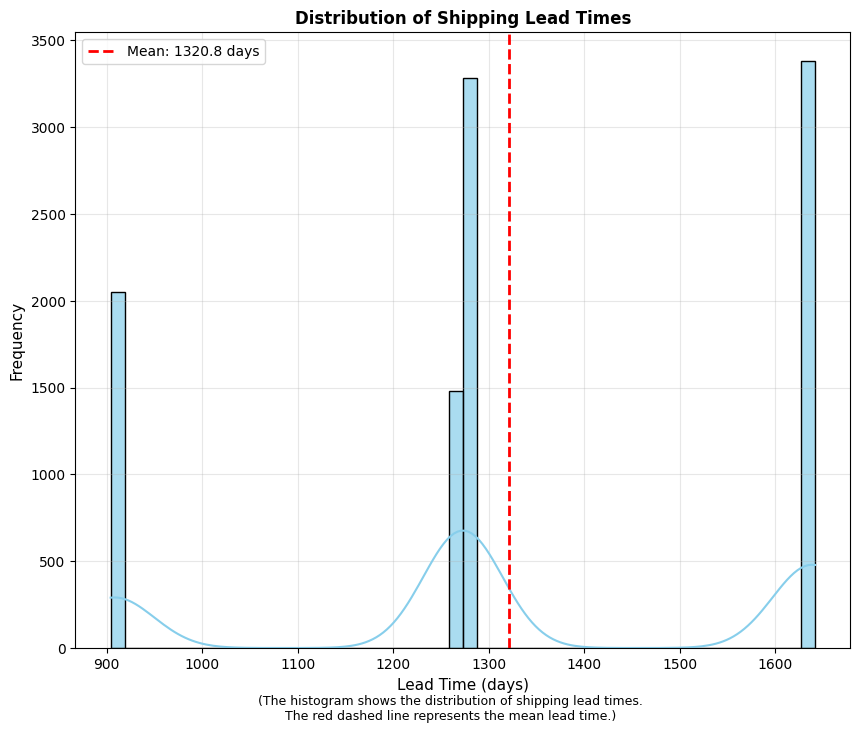

In [34]:
fig = plt.figure(figsize=(10, 8))
sns.histplot(df['Lead Time'], bins=50, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(df['Lead Time'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Lead Time"].mean():.1f} days')
plt.xlabel('Lead Time (days)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of Shipping Lead Times', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# explain the plot
plt.figtext(0.5, 0.02, "(The histogram shows the distribution of shipping lead times.\nThe red dashed line represents the mean lead time.)", ha="center", fontsize=9, color='black')

plt.savefig('01_lead_time_distribution.png', dpi=300)
print("Saved: 01_lead_time_distribution.png")




### 9.2 Box plot for regional

C:\Users\Neeraj_Thakur\AppData\Local\Temp\ipykernel_12720\34328238.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Lead Time', data=df, palette='Set2')


Saved: 02_lead_time_by_region.png


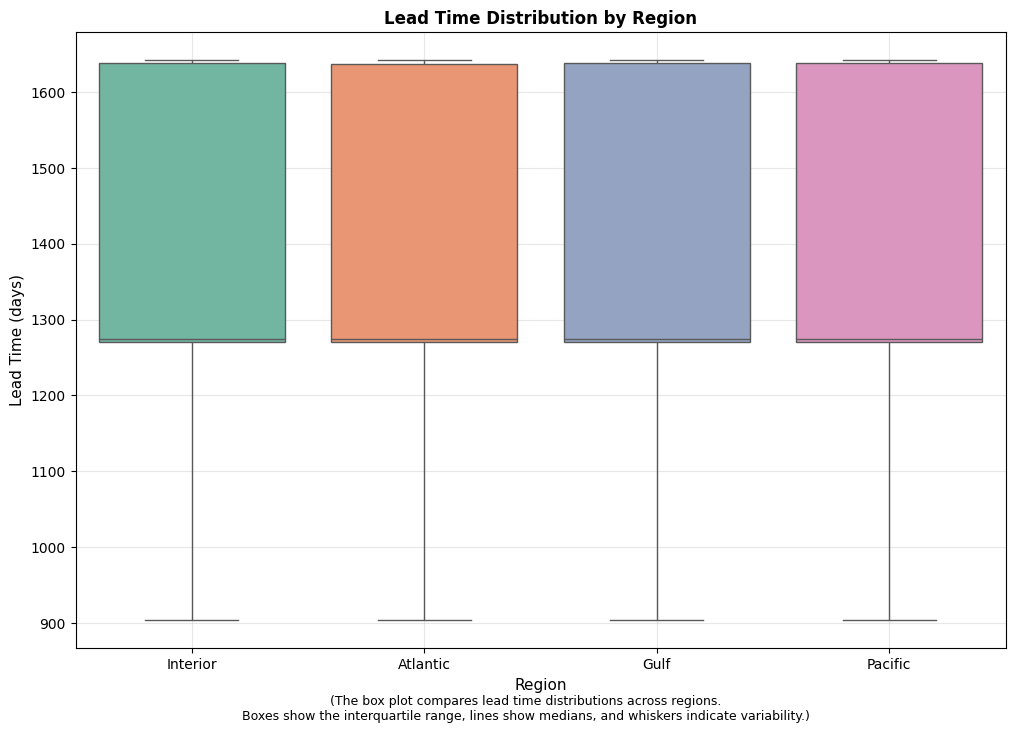

In [35]:
fig = plt.figure(figsize=(12, 8))
sns.boxplot(x='Region', y='Lead Time', data=df, palette='Set2')
plt.xlabel('Region', fontsize=11)
plt.ylabel('Lead Time (days)', fontsize=11)
plt.title('Lead Time Distribution by Region', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

plt.figtext(0.5, 0.02, "(The box plot compares lead time distributions across regions.\nBoxes show the interquartile range, lines show medians, and whiskers indicate variability.)", ha="center", fontsize=9, color='black')
plt.savefig('02_lead_time_by_region.png', dpi=300)
print("Saved: 02_lead_time_by_region.png")


### 9.3 Bottom 10 routes

C:\Users\Neeraj_Thakur\AppData\Local\Temp\ipykernel_12720\404800781.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Lead Time', y='Route', data=route_lead_time, palette='viridis')


Saved: 03_top_10_slowest_routes.png


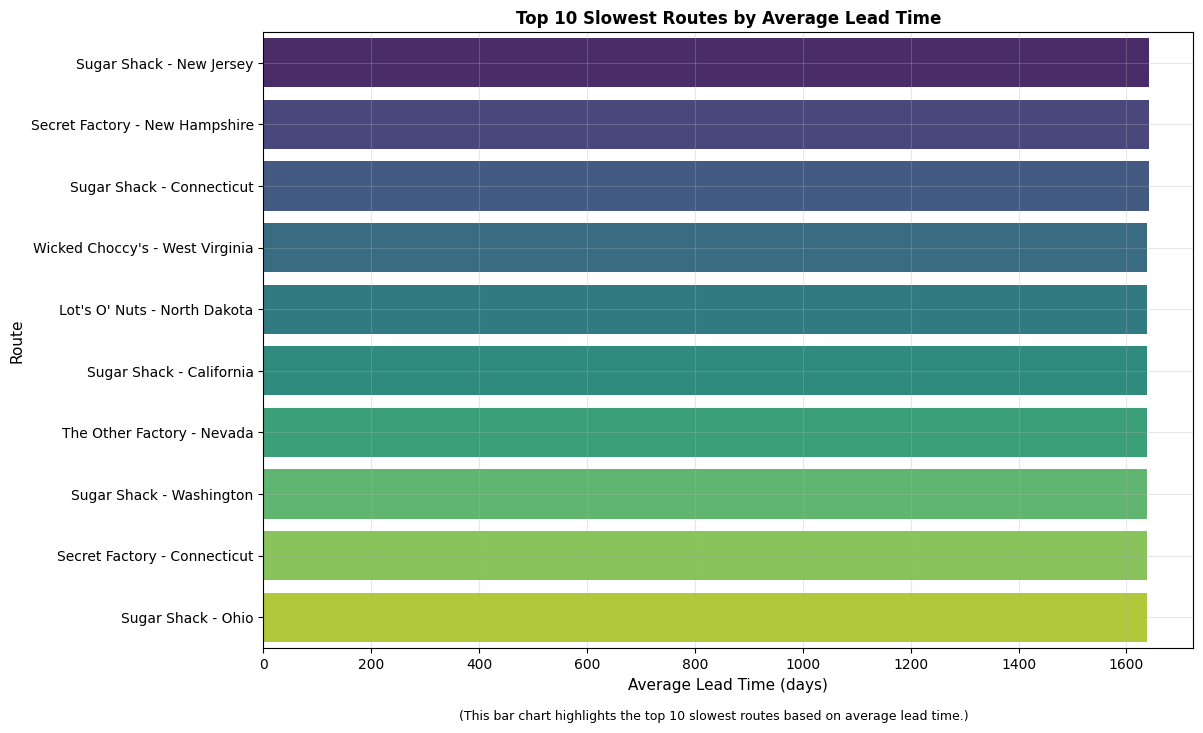

In [36]:
# Calculate average lead time by route
route_lead_time = df.groupby('Route')['Lead Time'].mean().reset_index()
route_lead_time = route_lead_time.sort_values('Lead Time', ascending=False).head(10)
fig = plt.figure(figsize=(12, 8))
sns.barplot(x='Lead Time', y='Route', data=route_lead_time, palette='viridis')
plt.xlabel('Average Lead Time (days)', fontsize=11)
plt.ylabel('Route', fontsize=11)
plt.title('Top 10 Slowest Routes by Average Lead Time', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.figtext(0.5, 0.02, "(This bar chart highlights the top 10 slowest routes based on average lead time.)", ha="center", fontsize=9, color='black')
plt.savefig('03_top_10_slowest_routes.png', dpi=300)
print("Saved: 03_top_10_slowest_routes.png")


### 9.4 Regional performance 

Saved: 04_regional_performance.png


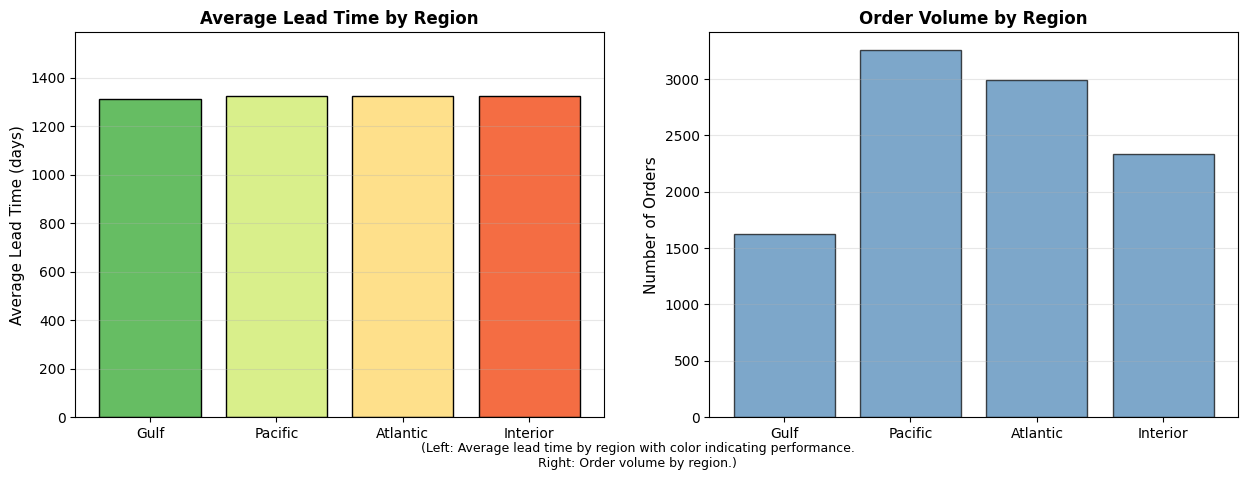

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
# Regional lead time
regional_plot = regional_metrics.sort_values('Avg_Lead_Time')
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(regional_plot)))
axes[0].bar(regional_plot['Region'], regional_plot['Avg_Lead_Time'], color=colors, edgecolor='black')
axes[0].set_ylabel('Average Lead Time (days)', fontsize=11)
axes[0].set_title('Average Lead Time by Region', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, regional_plot['Avg_Lead_Time'].max() * 1.2)
 
# Regional volume
axes[1].bar(regional_plot['Region'], regional_plot['Order_Count'], color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Number of Orders', fontsize=11)
axes[1].set_title('Order Volume by Region', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
 
# explain the plots
plt.figtext(0.5, 0.01, "(Left: Average lead time by region with color indicating performance.\nRight: Order volume by region.)", ha="center", fontsize=9, color='black')
plt.savefig('04_regional_performance.png', dpi=300, bbox_inches='tight')
print("Saved: 04_regional_performance.png")



### 9.4 Shipping mode comparison

Saved: 05_ship_mode_analysis.png


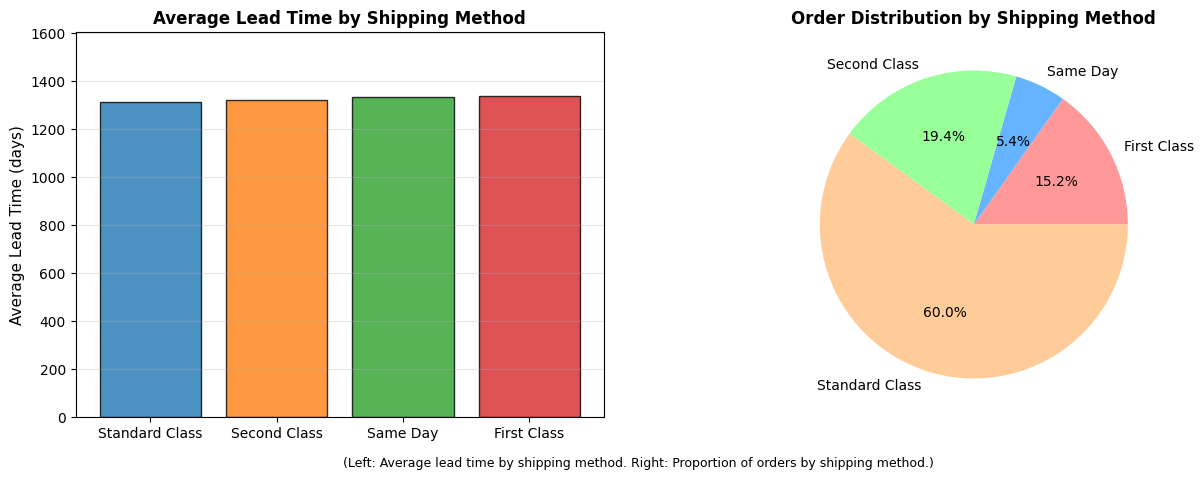

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
mode_plot = mode_metrics.sort_values('Avg_Lead_Time')
colors_mode = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(mode_plot)]
 
axes[0].bar(mode_plot['Ship Mode'], mode_plot['Avg_Lead_Time'], color=colors_mode, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Average Lead Time (days)', fontsize=11)
axes[0].set_title('Average Lead Time by Shipping Method', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, mode_plot['Avg_Lead_Time'].max() * 1.2)
 
axes[1].pie(mode_metrics['Order_Count'], labels=mode_metrics['Ship Mode'], autopct='%1.1f%%',
            colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
axes[1].set_title('Order Distribution by Shipping Method', fontsize=12, fontweight='bold')
 
fig.text(0.5, 0.01, "(Left: Average lead time by shipping method. Right: Proportion of orders by shipping method.)", ha="center", fontsize=9, color='black')
plt.savefig('05_ship_mode_analysis.png', dpi=300, bbox_inches='tight')
print("Saved: 05_ship_mode_analysis.png")


### 9.5 Bottleneck analysis

Saved: 06_bottleneck_heatmap.png


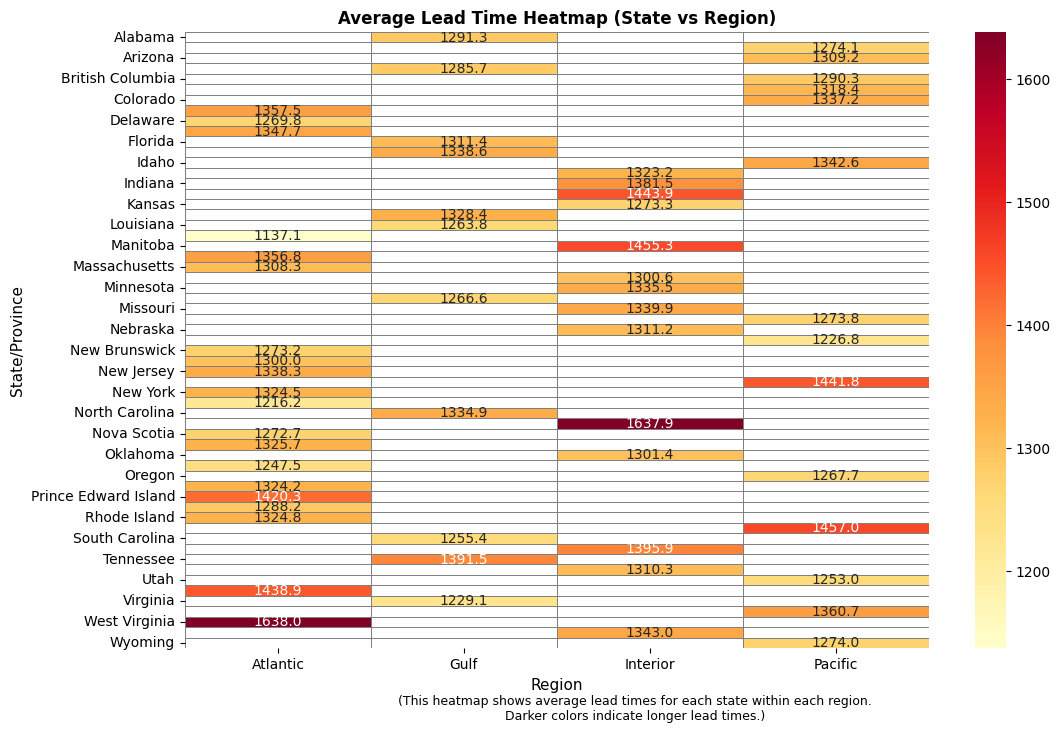

In [39]:
fig, ax = plt.subplots(figsize=(12, 8))
 
heatmap_data = df.pivot_table(
    index='State/Province', 
    columns='Region', 
    values='Lead Time', 
    aggfunc='mean'
)   
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='YlOrRd', linewidths=0.5, linecolor='gray')
plt.title('Average Lead Time Heatmap (State vs Region)', fontsize=12, fontweight
='bold')
plt.xlabel('Region', fontsize=11)
plt.ylabel('State/Province', fontsize=11)
plt.figtext(0.5, 0.02, "(This heatmap shows average lead times for each state within each region.\nDarker colors indicate longer lead times.)", ha="center", fontsize=9, color='black')
plt.savefig('06_bottleneck_heatmap.png', dpi=300, bbox_inches='tight')
print("Saved: 06_bottleneck_heatmap.png")



### 9.6 Factory performance analysis

Saved: 07_factory_performance.png


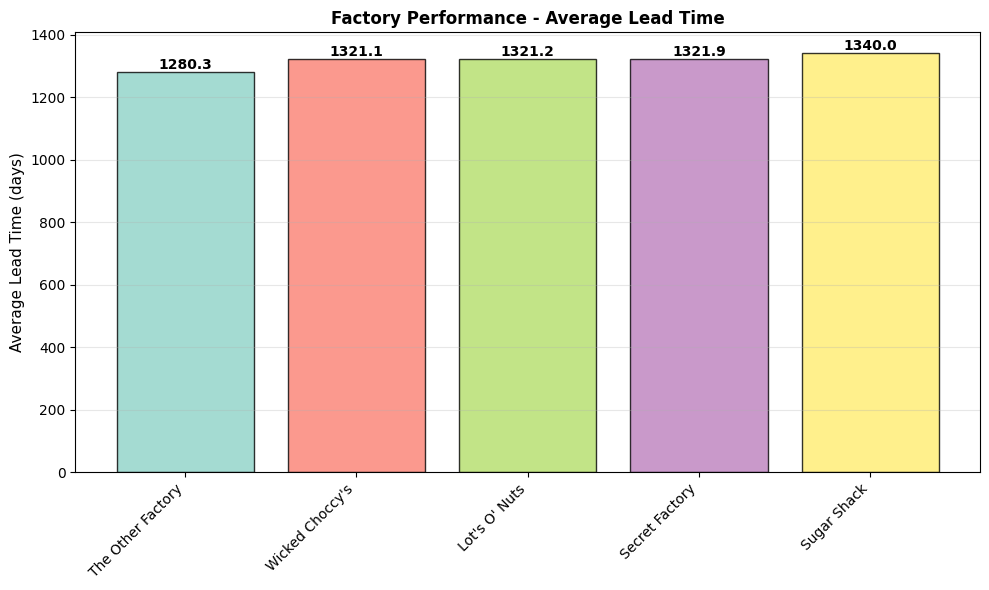

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
 
factory_plot = factory_metrics.sort_values('Avg_Lead_Time')
colors_factory = plt.cm.Set3(np.linspace(0, 1, len(factory_plot)))
 
bars = ax.bar(factory_plot['Factory'], factory_plot['Avg_Lead_Time'], color=colors_factory, edgecolor='black', alpha=0.8)
 
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
 
ax.set_ylabel('Average Lead Time (days)', fontsize=11)
ax.set_title('Factory Performance - Average Lead Time', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('07_factory_performance.png', dpi=300, bbox_inches='tight')
print("Saved: 07_factory_performance.png")


# Summary

In [41]:
print("\n" + "=" * 80)
print("DATA PROCESSING COMPLETE!")
print("=" * 80)
 
print("\nDELIVERABLES CREATED:")
print("  Data Files:")
print("    - processed_data.csv (Main dataset with features)")
print("    - route_metrics.csv (Route-level analysis)")
print("    - regional_metrics.csv (Regional analysis)")
print("    - state_metrics.csv (State-level analysis)")
print("    - mode_metrics.csv (Shipping mode analysis)")
print("    - factory_metrics.csv (Factory analysis)")
print("    - summary_stats.json (Summary statistics)")
print("\n  Visualizations:")
print("    - 01_lead_time_distribution.png")
print("    - 02_top_10_routes.png")
print("    - 03_bottom_10_routes.png")
print("    - 04_regional_performance.png")
print("    - 05_ship_mode_analysis.png")
print("    - 06_bottleneck_heatmap.png")
print("    - 07_factory_performance.png")



DATA PROCESSING COMPLETE!

DELIVERABLES CREATED:
  Data Files:
    - processed_data.csv (Main dataset with features)
    - route_metrics.csv (Route-level analysis)
    - regional_metrics.csv (Regional analysis)
    - state_metrics.csv (State-level analysis)
    - mode_metrics.csv (Shipping mode analysis)
    - factory_metrics.csv (Factory analysis)
    - summary_stats.json (Summary statistics)

  Visualizations:
    - 01_lead_time_distribution.png
    - 02_top_10_routes.png
    - 03_bottom_10_routes.png
    - 04_regional_performance.png
    - 05_ship_mode_analysis.png
    - 06_bottleneck_heatmap.png
    - 07_factory_performance.png
